# Feed Forward Neural Network

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from livelossplot import PlotLossesKerasTF

## Importing Data 

In [5]:
data = tf.keras.datasets.california_housing.load_data()

In [6]:
(train_data, train_labels), (test_data, test_labels) = data

np.random.seed(42)
tf.random.set_seed(42)

scalar = StandardScaler()
train_data = scalar.fit_transform(train_data)
test_data = scalar.transform(test_data)

In [7]:
train_data

array([[ 0.6457757 , -0.720931  ,  1.853275  , ..., -0.3331862 ,
        -0.02698462, -0.04505225],
       [ 0.6007986 , -0.781973  , -0.6076111 , ..., -0.12736215,
         0.14330858, -0.60169005],
       [-1.4130851 ,  1.0023164 ,  1.853275  , ..., -0.62376136,
        -0.26694322,  0.05375453],
       ...,
       [-1.3880975 ,  0.9131025 ,  1.853275  , ..., -0.481933  ,
        -0.367571  ,  2.313189  ],
       [-1.3081437 ,  1.0633583 , -0.84576136, ...,  0.17359067,
         0.60000396,  2.254748  ],
       [ 0.56581813, -0.66928023,  0.02745627, ...,  0.43995124,
         0.45809296, -0.39965   ]], shape=(16512, 8), dtype=float32)

## Architecting Model

In [8]:
model = models.Sequential([
    layers.Input(shape=(train_data.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='mse',
    metrics=['mae'],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,569 (178.00 KB)

 Trainable params: 45,569 (178.00 KB)

 Non-trainable params: 0 (0.00 B)

## Early Stopping and Training

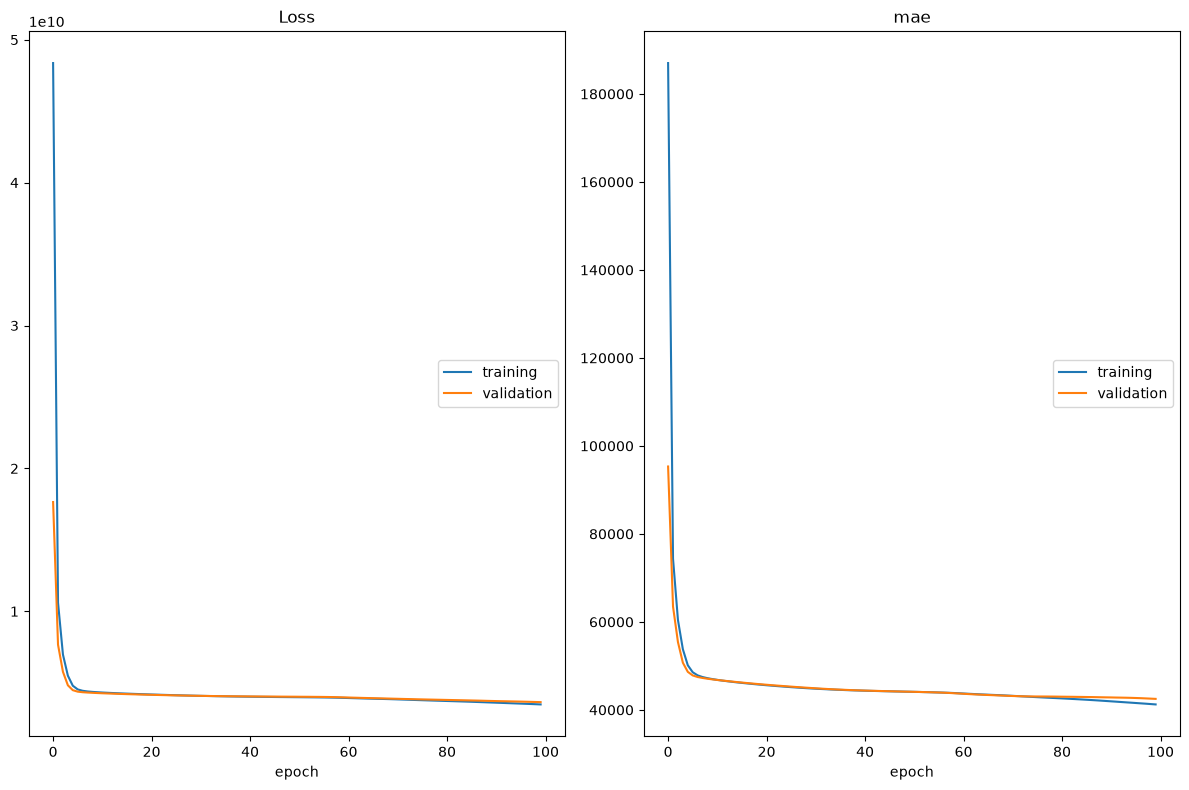

Loss
	training         	 (min: 3484408320.000, max: 48367337472.000, cur: 3484408320.000)
	validation       	 (min: 3645697792.000, max: 17646759936.000, cur: 3645697792.000)
mae
	training         	 (min: 41240.484, max: 187013.625, cur: 41240.484)
	validation       	 (min: 42502.906, max: 95318.195, cur: 42502.906)
104/104 - 0s - 2ms/step - loss: 3484408320.0000 - mae: 41240.4844 - val_loss: 3645697792.0000 - val_mae: 42502.9062 - learning_rate: 0.0020


In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    train_data,
    train_labels,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stopping, PlotLossesKerasTF(), tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)],
    verbose=2,
)

## Model Evaluation

In [10]:
test_loss, test_mae = model.evaluate(test_data, test_labels, verbose=2)
print(f'Test MSE: {test_loss:.4f}')
print(f'Test MAE: {test_mae:.4f}')
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")
print(f"Test R^2: {1 - (test_loss / np.var(test_labels)):.4f}")

sample_predictions = model.predict(test_data[:5], verbose=0).flatten()
print('Sample predictions:', sample_predictions)
print('Actual values:', test_labels[:5])

129/129 - 0s - 416us/step - loss: 3807920384.0000 - mae: 43368.3320
Test MSE: 3807920384.0000
Test MAE: 43368.3320
Test RMSE: 61708.3494
Test R^2: 0.7136
Sample predictions: [211837.77 291480.34 164192.31 359336.9  198841.56]
Actual values: [397900. 227900. 172100. 186500. 148900.]


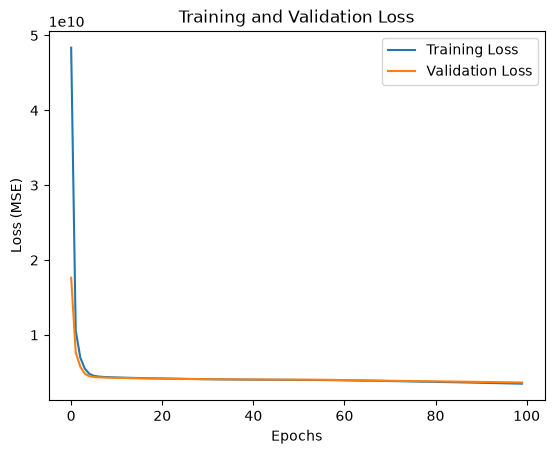

In [11]:
plt.Figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

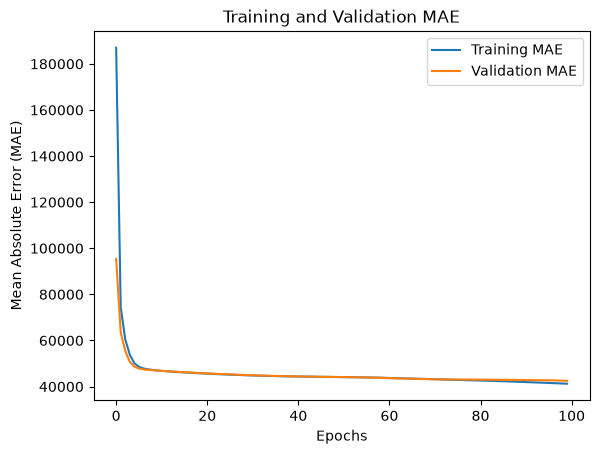

In [12]:
plt.Figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()

/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_25667/4165634267.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


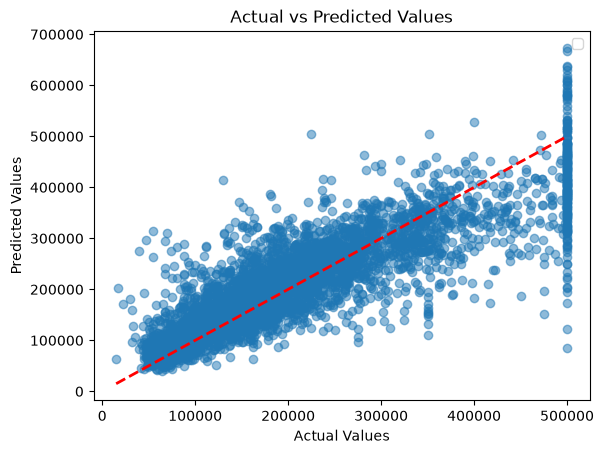

In [13]:
plt.Figure(figsize=(10, 6))
plt.scatter(test_labels, model.predict(test_data, verbose=0).flatten(), alpha=0.5)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([test_labels.min(), test_labels.max()], [test_labels.min(), test_labels.max()], 'r--', lw=2)
plt.legend()